# Logistic Regression with scikit-learn
Binary tweet sentiment classification — sklearn TfidfVectorizer + LogisticRegression full pipeline.

## 1. Load & Preprocess Tweets

In [1]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import twitter_samples, stopwords
import pandas as pd
import numpy as np
import re

STOPWORDS = set(stopwords.words('english'))

def clean(text: str) -> str:
    """Return a cleaned string (not tokenised — TfidfVectorizer handles tokenisation)."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

pos_tweets = twitter_samples.strings('positive_tweets.json')
neg_tweets = twitter_samples.strings('negative_tweets.json')

df = pd.DataFrame(
    [(clean(t), 1) for t in pos_tweets] + [(clean(t), 0) for t in neg_tweets],
    columns=['text', 'label']
)
print(f"Dataset: {len(df):,} tweets")
df.head(3)

Dataset: 10,000 tweets


,text,label
0,followfriday top engaged members community week,1
1,hey james odd please call contact centre able ...,1
2,listen last night bleed amazing track scotland,1


## 2. Train / Test Split (80/20, random_state=42)

In [2]:
from sklearn.model_selection import train_test_split

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f"Train: {len(X_raw_train):,}  |  Test: {len(X_raw_test):,}")

Train: 8,000  |  Test: 2,000


## 3. TF-IDF Vectorisation

`TfidfVectorizer` builds vocabulary, computes smoothed IDF, and L2-normalises
each document vector — identical to what we implemented manually in the earlier notebooks.

Key parameters:
- `max_features` — vocabulary cap
- `ngram_range=(1,2)` — unigrams + bigrams capture two-word phrases ("not good")
- `sublinear_tf=True` — replaces TF with 1+log(TF) to reduce impact of very frequent words

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_raw_train)   # fit on train only
X_test  = vectorizer.transform(X_raw_test)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Sparse matrix density: {X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.4%}")

X_train: (8000, 5000)  |  X_test: (2000, 5000)
Sparse matrix density: 0.1055%


## 4. Fit Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    C=1.0,           # inverse of regularisation strength — smaller = stronger regularisation
    solver='lbfgs',
    random_state=42
)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 5. Evaluation

In [5]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
import matplotlib.pyplot as plt

for label, X_s, y_s in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    y_pred = model.predict(X_s)
    acc    = accuracy_score(y_s, y_pred)
    auc    = roc_auc_score(y_s, model.predict_proba(X_s)[:, 1])
    print(f"{label:<6} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")

Train  | Accuracy: 0.8561 | ROC-AUC: 0.9313
Test   | Accuracy: 0.7560 | ROC-AUC: 0.8381


## 6. Classification Report

In [6]:
y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.74      0.79      0.76      1000
    Positive       0.77      0.72      0.75      1000

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



## 7. Confusion Matrix

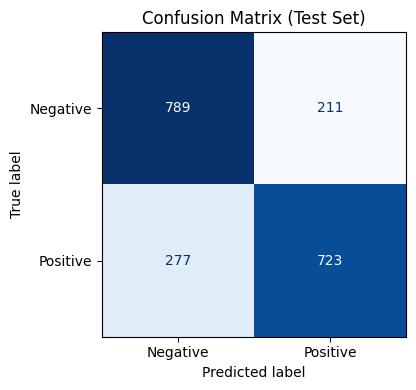

In [7]:
cm  = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 8. ROC Curve

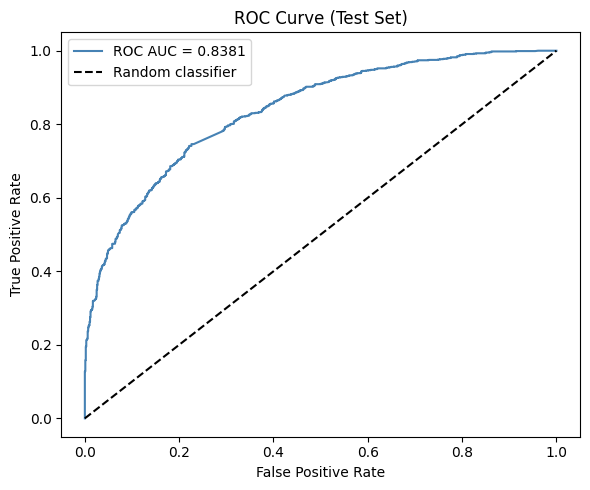

In [8]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.4f}', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Top Predictive N-grams

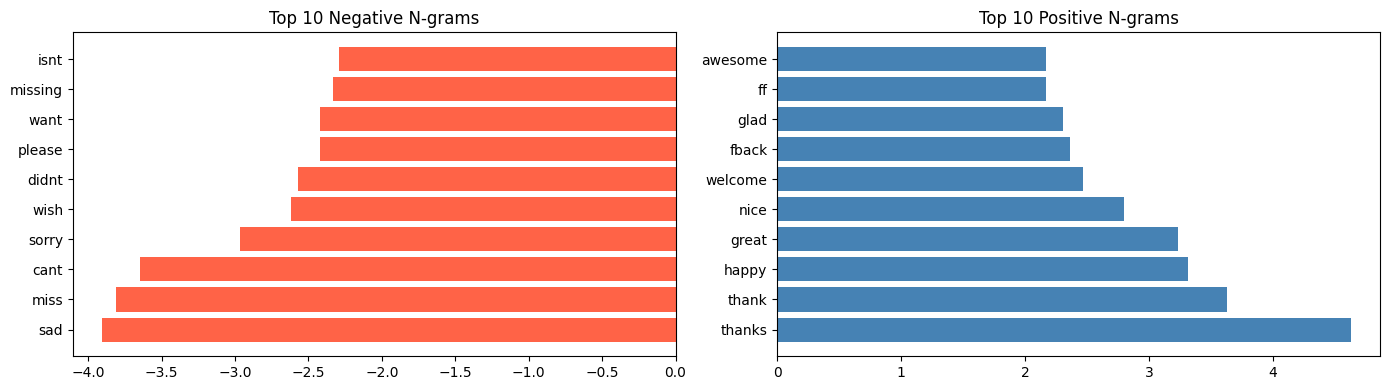

In [9]:
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]
order = np.argsort(coef)

top_neg = [(feature_names[i], coef[i]) for i in order[:10]]
top_pos = [(feature_names[i], coef[i]) for i in order[-10:][::-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.barh([w for w, _ in top_neg], [c for _, c in top_neg], color='tomato')
ax1.set_title('Top 10 Negative N-grams')
ax2.barh([w for w, _ in top_pos], [c for _, c in top_pos], color='steelblue')
ax2.set_title('Top 10 Positive N-grams')
plt.tight_layout()
plt.show()

## 10. Predict on Custom Tweets

Pass any tweet through the same `clean → vectorize → predict` pipeline.

In [10]:
def predict_tweet(tweet: str):
    cleaned = clean(tweet)
    vec     = vectorizer.transform([cleaned])
    prob    = model.predict_proba(vec)[0, 1]
    label   = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    print(f"Tweet:       {tweet}")
    print(f"Probability: {prob:.4f}")
    print(f"Sentiment:   {label}")
    print()

predict_tweet("I love this so much, absolutely amazing!")
predict_tweet("This is the worst day ever, I hate everything.")
predict_tweet("The flight was delayed but the crew was super helpful :)")
predict_tweet("Can't believe how bad the service was today. Never again.")

Tweet:       I love this so much, absolutely amazing!
Probability: 0.6375
Sentiment:   Positive 😊

Tweet:       This is the worst day ever, I hate everything.
Probability: 0.1856
Sentiment:   Negative 😞

Tweet:       The flight was delayed but the crew was super helpful :)
Probability: 0.6122
Sentiment:   Positive 😊

Tweet:       Can't believe how bad the service was today. Never again.
Probability: 0.1315
Sentiment:   Negative 😞



## 11. Effect of Regularisation Strength (C)

`C` = 1/λ. Lower C → stronger L2 regularisation → simpler model.  
Sweep C to see bias-variance tradeoff.

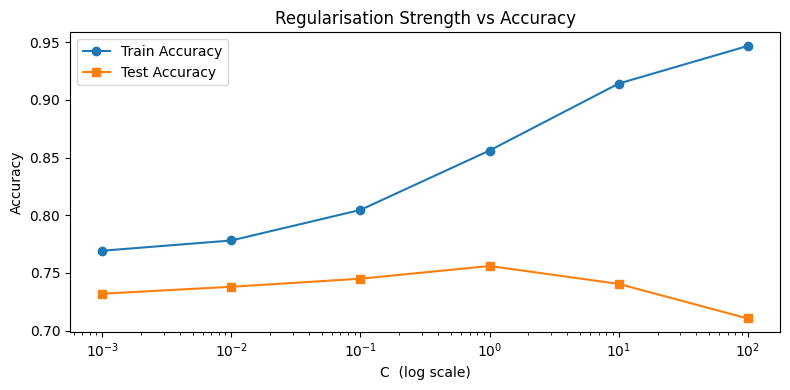

In [11]:
C_values    = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_accs  = []
test_accs   = []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, solver='lbfgs', random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.semilogx(C_values, train_accs, marker='o', label='Train Accuracy')
plt.semilogx(C_values, test_accs,  marker='s', label='Test Accuracy')
plt.xlabel('C  (log scale)')
plt.ylabel('Accuracy')
plt.title('Regularisation Strength vs Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Save Model to `../Models/`

In [12]:
import joblib, os

# Save vectorizer and model together as a dict — the comparison notebook
# loads both in one shot without needing to know the internal structure.
save_path = '../Models/logreg_sklearn.joblib'
joblib.dump({'vectorizer': vectorizer, 'model': model}, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/logreg_sklearn.joblib  (223.8 KB)
